In [1]:
#"Where are the most fire-affected African countries, and do fire intensity (FRP) and detection time (day/night) show a spatial pattern?"

In [6]:
# API Key : not pushed to GitHub (notebooks/ is in .gitignore)
map_key = "dc38faa964bb2d75d020b913a3579aa3"

In [2]:
import requests
import pandas as pd
import time
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches
import numpy as np
import folium

In [3]:
# API key  in .env file !!!! never push keys to GitHub!
with open("../.gitignore", "w") as f:
    f.write(".env\n")
#check if everything good
print(os.path.exists("../.env"))       
print(os.path.exists("../.gitignore")) 

True
True


In [4]:
for root, dirs, files in os.walk(".."):
    # skip hidden folders like .git
    dirs[:] = [d for d in dirs if not d.startswith(".")]
    level = root.replace("..", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    {file}")

../
    .DS_Store
    README.md
    .gitignore
    .env
    data/
        .DS_Store
        ne_110m_admin_0_countries/
            ne_110m_admin_0_countries.shx
            ne_110m_admin_0_countries.shp
            ne_110m_admin_0_countries.cpg
            ne_110m_admin_0_countries.VERSION.txt
            ne_110m_admin_0_countries.dbf
            ne_110m_admin_0_countries.README.html
            ne_110m_admin_0_countries.prj
    outputs/
    notebooks/
        .DS_Store
        wildfire_analysis.ipynb
        wildfire_utils.py
        area_calculation.ipynb
        fire_on_map.ipynb
        wildfire_duration.ipynb
        __pycache__/
            wildfire_utils.cpython-314.pyc


In [6]:
%pwd

'/Users/marai/SDS210/project-wildfire/notebooks'

In [7]:
url_api = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/VIIRS_SNPP_NRT/world/5"

response = requests.get(url_api)
print(response.status_code)
print(response.text[:200]) 
    
fires_df = pd.read_csv(url_api)

200
latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
22.70248,39.04295,307.43,0.5,0.66,2026-05-12,1,N,VIIRS,n,2.0NRT,292.96,1.04,N


In [8]:
##inspect and clean the data
# Check for missing values
fires_df.isnull().sum() # every thing 0 so no missing data

latitude      0
longitude     0
bright_ti4    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
dtype: int64

In [8]:
## convert coordinate into geometry
import geopandas as gpd

fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df['longitude'], fires_df['latitude']),
    crs='EPSG:4326')

## load world and subset just africa
import os
os.getcwd() #prints current working directory
os.listdir("../data") # ... = go up one folder
os.listdir("../data/ne_110m_admin_0_countries")

world = gpd.read_file("../data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
africa = world[world["CONTINENT"] == "Africa"]

#spatial join: filters detections to Africa only and attaches country name to each fire point based on geographic location
fires_africa = gpd.sjoin(
    fires_gdf,
    africa[["geometry", "NAME"]],
    how="inner", #only matching points are kept that are in African polygon 
    predicate="within") #point must be fully inside the polygon


In [9]:
# check what we have before starting the analysis
print(f"Total fire detections in Africa: {len(fires_africa):,}")
print(fires_africa["daynight"].value_counts())

Total fire detections in Africa: 52,644
daynight
D    48287
N     4357
Name: count, dtype: int64


In [10]:
##Convert date + time into a proper datetime
fires_africa["acq_time"] = fires_africa["acq_time"].astype(str).str.zfill(4) #zfill: HHMM->"0930", "0054"

fires_africa["datetime"] = pd.to_datetime( # needs string to work : above converted acq_time to strimg
    fires_africa['acq_date'] + ' ' + #' ' = space -> besseren überblick
    fires_africa["acq_time"].str[:2] + ':' + #hours divided after by :
    fires_africa["acq_time"].str[2:], # minutes
    format="%Y-%m-%d %H:%M")

In [11]:
fires_africa["daynight"] = fires_africa["daynight"].map({"D": "Day", "N": "Night"})

fires_africa = fires_africa[["latitude", 
                             "longitude",
                             "NAME",                             
                             "bright_ti4", 
                             "frp", 
                             "daynight",
                             "acq_date",
                             "geometry"]]


fires_africa = fires_africa.rename(columns={
    "bright_ti4": "brightness",
    "acq_date": "date"
})
 
fires_africa.head()

,latitude,longitude,NAME,brightness,frp,daynight,date,geometry
4,24.95234,32.91698,Egypt,337.41,4.46,Night,2026-05-12,POINT (32.91698 24.95234)
5,24.95308,32.91320,Egypt,312.04,4.15,Night,2026-05-12,POINT (32.9132 24.95308)
6,26.69883,12.45149,Libya,322.86,2.66,Night,2026-05-12,POINT (12.45149 26.69883)
7,26.69924,12.44324,Libya,302.57,2.66,Night,2026-05-12,POINT (12.44324 26.69924)
8,26.75188,12.41038,Libya,324.97,6.20,Night,2026-05-12,POINT (12.41038 26.75188)


In [12]:
##do day and night detections differ in brightness and FRP? Yes

summary = fires_africa.groupby("daynight")[["brightness", "frp"]].agg(
    ["count", "mean", "median", "std"]
).round(2)

print(summary)

         brightness                           frp                    
              count    mean  median    std  count  mean median    std
daynight                                                             
Day           48287  339.75  337.84   8.78  48287  8.48   5.43  11.86
Night          4357  311.60  308.12  12.75   4357  2.98   1.39  11.66


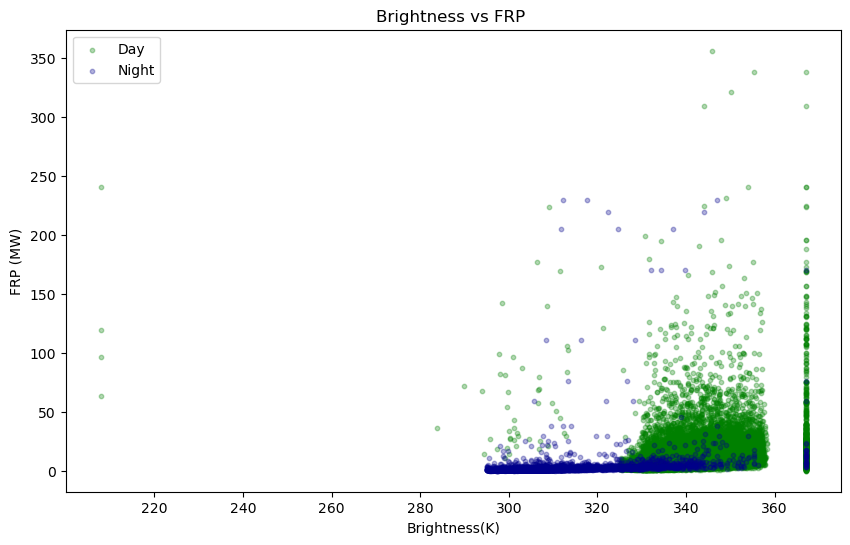

In [13]:
## correlation btw bright. and frp 

fig, ax = plt.subplots(figsize=(10, 6))

for group, color in [("Day", "green"), ("Night", "darkblue")]:
    subset = fires_africa[fires_africa["daynight"] == group]
    ax.scatter(subset["brightness"], subset["frp"], 
               alpha=0.3, s=10, color=color, label=group)

ax.set_xlabel("Brightness(K)")
ax.set_ylabel("FRP (MW)")
ax.set_title("Brightness vs FRP ")
ax.legend()
plt.show()

In [14]:
# how many detections per country — sorted by count
fires_africa.groupby("NAME")["frp"].agg(["count", "mean", "median"]
                                          ).round(2).sort_values("mean", ascending=False).rename(columns={
    "count": "fire_detections",
    "mean": "mean_frp",
    "median": "median_frp"
})

,fire_detections,mean_frp,median_frp
NAME,,,
Guinea,2521,18.56,7.69
eSwatini,12,16.81,3.74
Mauritania,68,16.16,14.84
Guinea-Bissau,320,13.40,7.75
Niger,339,10.80,6.67
Liberia,1750,10.32,6.94
Mali,885,10.05,6.45
Lesotho,2,10.00,10.00
S. Sudan,1060,9.23,5.88


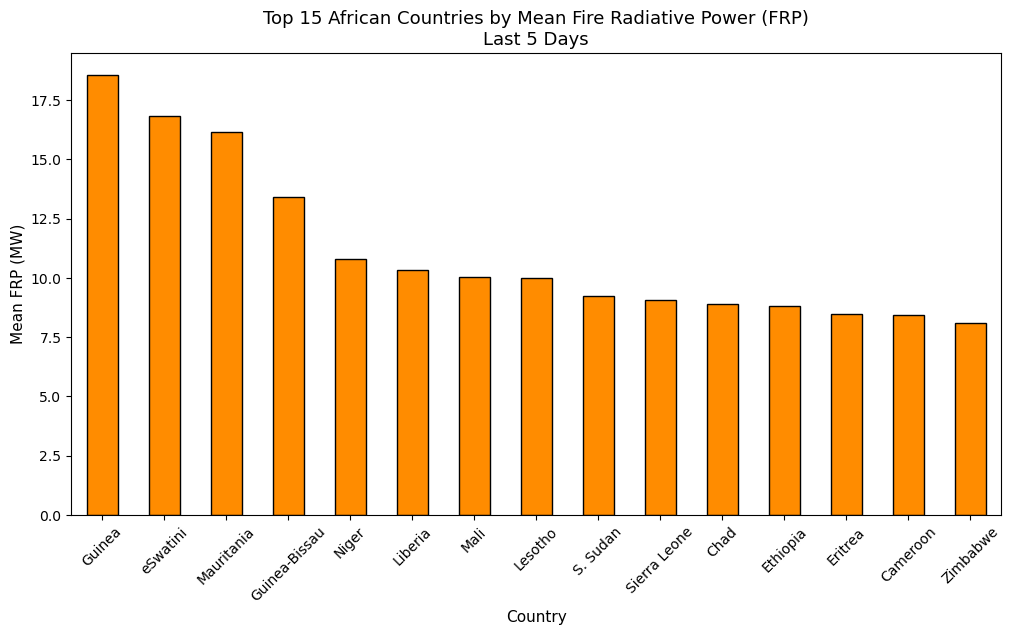

In [15]:
top_countries = (fires_africa.groupby("NAME")["frp"]
                 .mean()
                 .round(2)
                 .sort_values(ascending=False)
                 .head(15))

fig, ax = plt.subplots(figsize=(12, 6))

top_countries.plot(kind="bar", ax=ax, color="#FF8C00", edgecolor="black")

ax.set_title("Top 15 African Countries by Mean Fire Radiative Power (FRP)\nLast 5 Days", 
             fontsize=13)

ax.set_xlabel("Country", fontsize=11)
ax.set_ylabel("Mean FRP (MW)", fontsize=11)
ax.tick_params(axis="x", rotation=45)

plt.show()

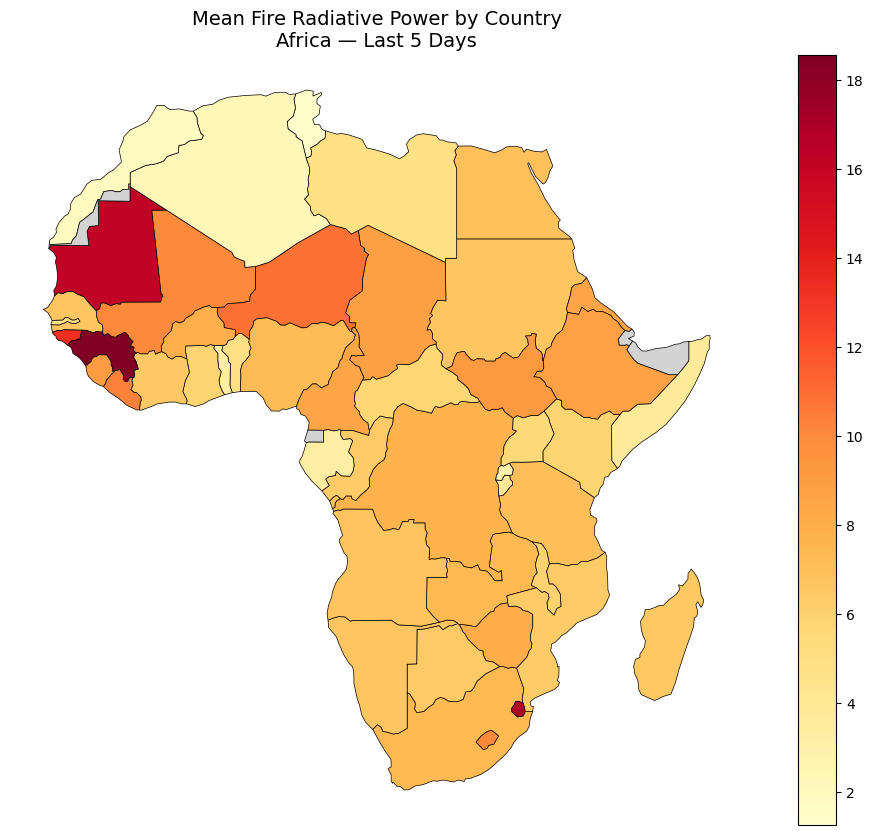

In [16]:
# calculate mean FRP per country

frp_by_country = fires_africa.groupby("NAME")["frp"].mean().round(2).reset_index()
frp_by_country.columns = ["NAME", "mean_frp"]

# merge by "NAME"
africa_frp = africa.merge(frp_by_country, on="NAME", how="left") 
#keep all rows from the left table (africa shapefile) 
    #even if there's no match in the right table (frp_by_country)

##Choropleth map 
fig, ax = plt.subplots(figsize=(14, 10))
africa_frp.plot(
    column="mean_frp",
    cmap="YlOrRd", # yellow to red
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Mean Fire Radiative Power by Country\nAfrica — Last 5 Days", 
             fontsize=14)
ax.axis("off")
plt.show()

In [ ]:
from folium.features import GeoJsonTooltip
import json

country_stats = (fires_africa.groupby("NAME")["frp"]
                 .agg(count="count")
                 .round(2)
                 .reset_index())

country_stats.columns = ["NAME", "fire_count"]

africa_map = africa.merge(country_stats, on="NAME", how="left")
africa_geojson = json.loads(africa_map.to_json())

m = folium.Map(location=[0, 20], zoom_start=4, tiles="CartoDB dark_matter")

folium.Choropleth(
    geo_data= africa_geojson, #GeoJSON format : convert with geopandas
    data=country_stats,
    columns=["NAME", "fire_count"],
    key_on="feature.properties.NAME",
    fill_color="YlOrRd",        # yellow to red 
    fill_opacity=0.6,
    line_opacity=0.5,
    legend_name="Number of Fire Detections",
    nan_fill_color="lightgrey"  # countries with no fires
).add_to(m)

colors = {"Day": "#FF8C00", "Night": "#4FC3F7"}

for _, row in fires_africa.iterrows():

    color = colors.get(row["daynight"], "grey")

    # scale FRP to marker size — clamp between 3 and 20px
    radius = min(max(row["frp"] / 15, 3), 20)

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        weight=0.5,
        tooltip = folium.Tooltip(f"<b>{row['NAME']}</b><br>"# when you hover over a point: see country name in bold and br inserts line break 
           f"FRP: {row['frp']:.1f} MW<br>"
           f"Date: {row["date"]}<br>"  
           f"Time of day: <b>{row["daynight"]}<br>")
        )
    ).add_to(m)

m